In [41]:
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, pointbiserialr, ttest_ind, shapiro, normaltest, mannwhitneyu

sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

# Set color palette for seaborn
# sns.set_palette("husl")

In [42]:
# Define consistent color palette for the entire analysis
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Gender color mapping for easy reference
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE,
    'Combined': COLOR_COMBINED
}

# Total Analysis of Exam Performance with focus on gender and time - IN1020 2023

## Research Questions:
- Are there significant performance differences between male and female students?
- How do time completion patterns differ by gender?
- What is the magnitude of any observed differences?
- Are the differences practically significant for educational outcomes?

## 1. Data Loading

In [43]:
df = load_data("../data/cleaned_data/IN1020_2023_cleaned_data.csv")

Data loaded successfully from ../data/cleaned_data/IN1020_2023_cleaned_data.csv


## 2. Data Preparation

We'll prepare separate datasets for different analyses:
- **df_combined**: One record per student with gender and total score
- **df_time**: data including exam timing information
- **df_male**: Data about total score among male students
- **df_male**: Data about total score among female students

In [44]:
# Prepare student-level dataset with unique records per student
df_combined = df.groupby('student_id').agg({
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

# Create gender-specific subsets for analysis
df_male = df_combined[df_combined['gender'] == 'M']
df_female = df_combined[df_combined['gender'] == 'F']

# Prepare a subset for exam time analysis
df_time = df.groupby('student_id').agg({
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

#add column with time taken to complete the exam in minutes
df_time['time_taken'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)

In [45]:
print("Combined dataset (male and female students):")
df_combined.head()

Combined dataset (male and female students):


,student_id,gender,total_score
0,1,M,69.33
1,2,F,68.50
2,3,F,67.00
3,4,F,48.00
4,5,F,70.00


In [46]:
print("Dataset with only male students:")
df_male.head()

Dataset with only male students:


,student_id,gender,total_score
0,1,M,69.33
5,6,M,71.83
9,10,M,63.00
10,11,M,56.50
13,14,M,88.86


In [47]:
print("Dataset with only female students:")
df_female.head()

Dataset with only female students:


,student_id,gender,total_score
1,2,F,68.5
2,3,F,67.0
3,4,F,48.0
4,5,F,70.0
6,7,F,27.0


In [48]:
print("Dataset with time taken to complete the exam:")
df_time.head()

Dataset with time taken to complete the exam:


,student_id,exam_start_time,exam_end_time,gender,total_score,time_taken
0,1,2023-12-11 08:00:04,2023-12-11 11:50:07,M,69.33,230.05
1,2,2023-12-11 08:00:02,2023-12-11 12:29:29,F,68.50,269.45
2,3,2023-12-11 08:00:02,2023-12-11 11:51:38,F,67.00,231.60
3,4,2023-12-11 08:00:07,2023-12-11 11:41:39,F,48.00,221.53
4,5,2023-12-11 08:00:08,2023-12-11 11:58:49,F,70.00,238.68


## 3. Descriptive Statistics

Let's examine the central tendencies, variability, and distribution characteristics of exam scores by gender.

In [49]:
# Enhanced descriptive statistics table
def calculate_descriptive_stats(data, name):
    """Calculate comprehensive descriptive statistics"""
    stats_dict = {
        'Count': len(data),
        'Mean': round(data.mean(), 2),
        'Median': round(data.median(), 2),
        'Mode': round(data.mode()[0], 2),
        'Std Dev': round(data.std(), 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2),
        'Q1': round(data.quantile(0.25), 2),
        'Q3': round(data.quantile(0.75), 2),
        'IQR': round(data.quantile(0.75) - data.quantile(0.25), 2),
        'Skewness': round(data.skew(), 3),
        'Kurtosis': round(data.kurtosis(), 3)
    }
    return pd.Series(stats_dict, name=name)

# Create comprehensive statistics table
descriptive_stats = pd.DataFrame([
    calculate_descriptive_stats(df_combined['total_score'], 'Combined'),
    calculate_descriptive_stats(df_male['total_score'], 'Male'),
    calculate_descriptive_stats(df_female['total_score'], 'Female')
]).T

print("=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===")
print(descriptive_stats)

# Calculate mean difference and percentage difference but works for both situations when male score is higher and female score is higher
if df_male['total_score'].mean() > df_female['total_score'].mean():
    mean_diff = df_male['total_score'].mean() - df_female['total_score'].mean()
    pct_diff = (mean_diff / df_female['total_score'].mean()) * 100
    print(f"\n=== KEY FINDINGS ===")
    print(f"Mean difference (Male - Female): {mean_diff:.2f} points")
    print(f"Percentage difference: {pct_diff:.1f}%")
    print(f"Male performance is {'higher' if mean_diff > 0 else 'lower'} than female performance")
elif df_female['total_score'].mean() > df_male['total_score'].mean():
    mean_diff = df_female['total_score'].mean() - df_male['total_score'].mean()
    pct_diff = (mean_diff / df_male['total_score'].mean()) * 100
    print(f"\n=== KEY FINDINGS ===")
    print(f"Mean difference (Female - Male): {mean_diff:.2f} points")
    print(f"Percentage difference: {pct_diff:.1f}%")
    print(f"Female performance is {'higher' if mean_diff > 0 else 'lower'} than male performance")
else:
    print("\n=== KEY FINDINGS ===")
    print("No difference in mean scores between male and female students.")


=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===
          Combined     Male   Female
Count      590.000  327.000  263.000
Mean        64.040   66.440   61.050
Median      64.270   66.500   61.660
Mode        62.500   62.500   55.000
Std Dev     13.310   12.860   13.290
Min         19.500   19.500   21.150
Max         95.500   95.500   90.160
Q1          55.700   59.140   51.250
Q3          74.120   76.130   71.250
IQR         18.420   16.980   20.000
Skewness    -0.392   -0.487   -0.294
Kurtosis    -0.036    0.281   -0.238

=== KEY FINDINGS ===
Mean difference (Male - Female): 5.39 points
Percentage difference: 8.8%
Male performance is higher than female performance


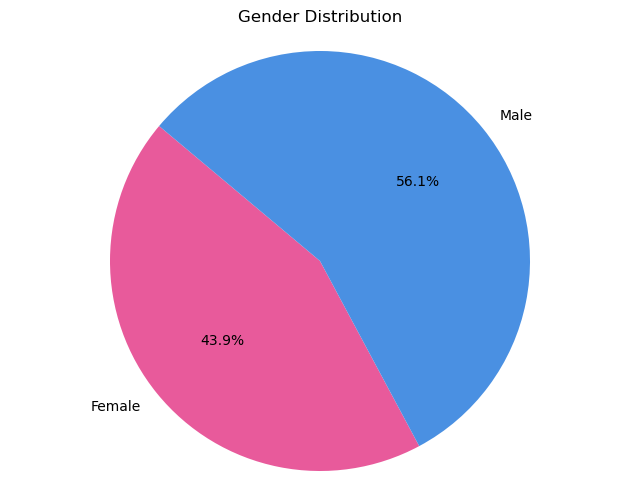

In [50]:
# Gender distribution pie chart
plt.figure(figsize=(8, 6))
# Ensure consistent order: Female first, then Male
gender_counts = df['gender'].value_counts().reindex(['F', 'M'])
plt.pie(gender_counts, autopct='%1.1f%%', 
        colors=[COLOR_FEMALE, COLOR_MALE], 
        startangle=140,
        labels=['Female', 'Male'])
plt.title("Gender Distribution")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

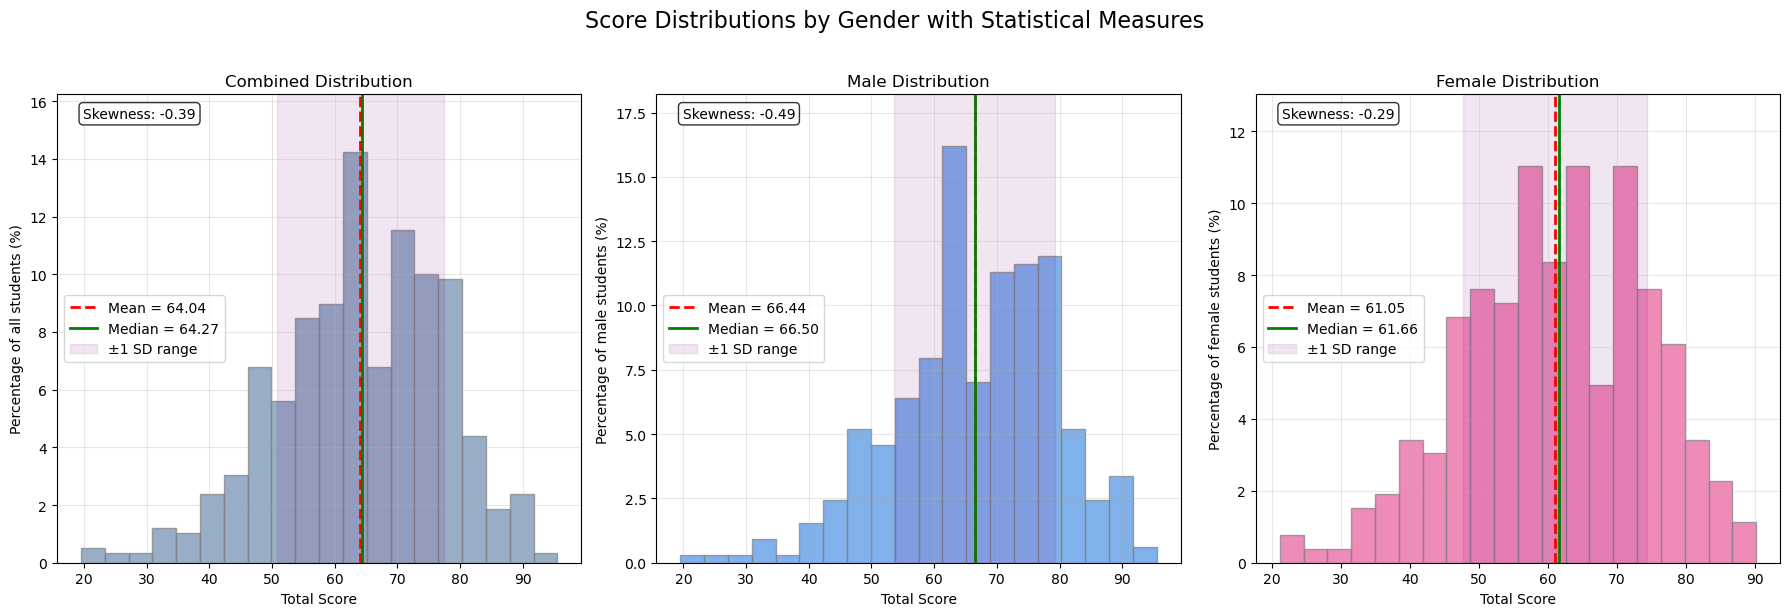

=== DISTRIBUTION SHAPE INTERPRETATION ===
Combined: approximately symmetric (skewness = -0.392)
Male: approximately symmetric (skewness = -0.487)
Female: approximately symmetric (skewness = -0.294)


In [51]:
def plot_enhanced_distributions(df, axes, title, ylabel, color='lightblue'):
    """Create enhanced distribution plots with statistical annotations"""
    mean_val = df['total_score'].mean()
    median_val = df['total_score'].median()
    std_val = df['total_score'].std()
    skew_val = df['total_score'].skew()
    
    total_students = len(df)
    
    # Create histogram with percentage weights
    n, bins, patches = axes.hist(df['total_score'], bins=20, color=color, edgecolor='gray', alpha=0.7, 
             weights=np.ones(len(df))/total_students*100)
    
    # Add statistical lines
    axes.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    axes.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
    axes.axvspan(mean_val - std_val, mean_val + std_val, color='purple', alpha=0.1, label='±1 SD range')
    
    # Add skewness annotation
    axes.text(0.05, 0.95, f'Skewness: {skew_val:.2f}', transform=axes.transAxes, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes.set_xlabel("Total Score")
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.grid(True, alpha=0.3)
    # Set y-limit to maximum y-value plus 5
    max_y = max(n)
    axes.set_ylim(0, max_y+2)
    axes.legend()

# Create enhanced distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_enhanced_distributions(df_combined, axes[0], "Combined Distribution", 
                          "Percentage of all students (%)", COLOR_COMBINED)
plot_enhanced_distributions(df_male, axes[1], "Male Distribution", 
                          "Percentage of male students (%)", COLOR_MALE)
plot_enhanced_distributions(df_female, axes[2], "Female Distribution", 
                          "Percentage of female students (%)", COLOR_FEMALE)

plt.suptitle("Score Distributions by Gender with Statistical Measures", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Interpretation of skewness
print("=== DISTRIBUTION SHAPE INTERPRETATION ===")
for name, data in [("Combined", df_combined), ("Male", df_male), ("Female", df_female)]:
    skew = data['total_score'].skew()
    if abs(skew) < 0.5:
        shape = "approximately symmetric"
    elif skew > 0.5:
        shape = "right-skewed (positive skew)"
    else:
        shape = "left-skewed (negative skew)"
    print(f"{name}: {shape} (skewness = {skew:.3f})")

### Outlier Analysis

=== OUTLIER ANALYSIS ===
Combined: 5 outliers (0.8%)
  Range: 19.50 - 27.00
Male: 5 outliers (1.5%)
  Range: 19.50 - 32.00
Female: 1 outliers (0.4%)
  Range: 21.15 - 21.15


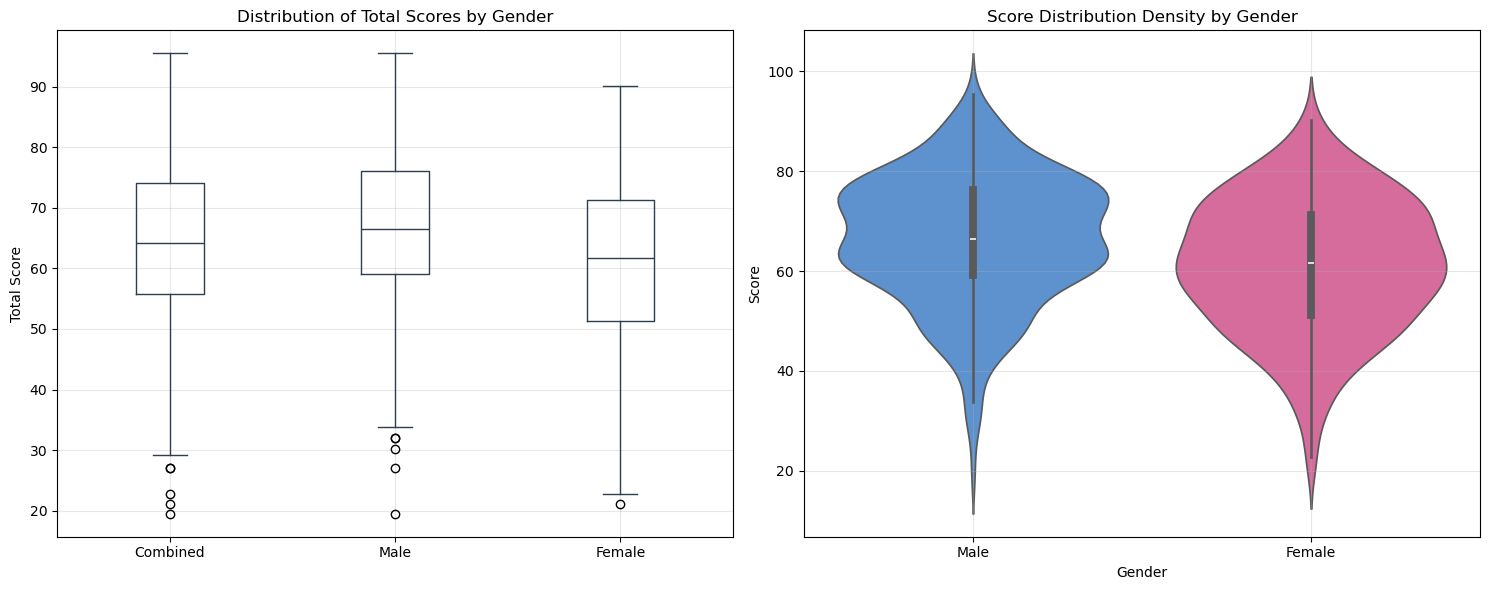

In [52]:
# Enhanced boxplot analysis with outlier identification
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Score outliers
df_outliers = pd.DataFrame({
    'Combined': df_combined['total_score'],
    'Male': df_male['total_score'],
    'Female': df_female['total_score']
})

boxplot1 = df_outliers.boxplot(ax=ax1, return_type='dict', color=COLOR_BOXPLOT)
ax1.set_title('Distribution of Total Scores by Gender')
ax1.set_ylabel('Total Score')
ax1.grid(True, alpha=0.3)

# Identify outliers using IQR method
def identify_outliers(data, name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{name}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range: {outliers.min():.2f} - {outliers.max():.2f}")
    return outliers

print("=== OUTLIER ANALYSIS ===")
combined_outliers = identify_outliers(df_combined['total_score'], "Combined")
male_outliers = identify_outliers(df_male['total_score'], "Male")
female_outliers = identify_outliers(df_female['total_score'], "Female")

# Violin plot for better distribution visualization
df_melted = pd.melt(df_outliers.reset_index(), id_vars='index', 
                    value_vars=['Male', 'Female'], 
                    var_name='Gender', value_name='Score')
df_melted = df_melted.dropna()

sns.violinplot(data=df_melted, x='Gender', y='Score', hue='Gender', ax=ax2, 
               palette={'Male': COLOR_MALE, 'Female': COLOR_FEMALE}, legend=False)
ax2.set_title('Score Distribution Density by Gender')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Time Analysis

In [53]:
# Time analysis descriptive statistics
time_stats = pd.DataFrame([
    calculate_descriptive_stats(df_time['time_taken'], 'Combined'),
    calculate_descriptive_stats(df_time[df_time['gender'] == 'M']['time_taken'], 'Male'),
    calculate_descriptive_stats(df_time[df_time['gender'] == 'F']['time_taken'], 'Female')
]).T

print("=== TIME ANALYSIS DESCRIPTIVE STATISTICS ===")
print(time_stats)

=== TIME ANALYSIS DESCRIPTIVE STATISTICS ===
          Combined     Male   Female
Count      590.000  327.000  263.000
Mean       205.840  194.970  219.360
Median     226.460  208.000  235.380
Mode       240.050  240.050  239.530
Std Dev     43.950   46.390   36.520
Min         44.580   44.580   93.200
Max        300.670  271.180  300.670
Q1         180.420  164.180  207.980
Q3         239.020  236.340  239.860
IQR         58.590   72.160   31.880
Skewness    -1.064   -0.800   -1.474
Kurtosis     0.348   -0.328    2.027


=== TIME OUTLIER ANALYSIS ===
Combined Time: 6 outliers (1.0%)
  Range: 44.58 - 91.32
Male Time: 1 outliers (0.3%)
  Range: 44.58 - 44.58
Female Time: 27 outliers (10.3%)
  Range: 93.20 - 300.67


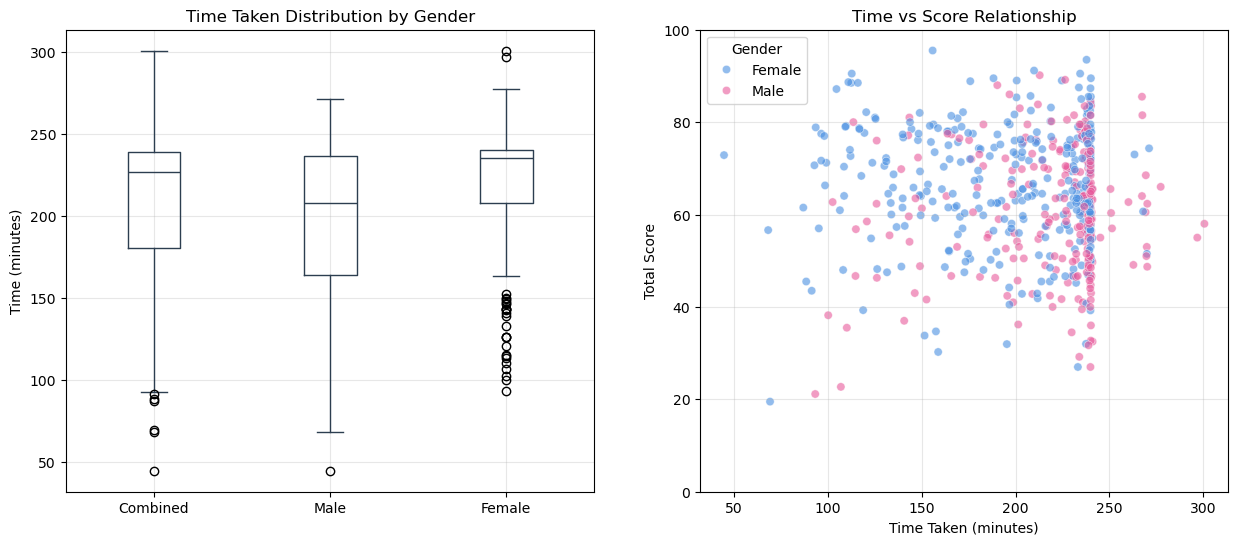

<Figure size 640x480 with 0 Axes>

In [54]:
# Enhanced time analysis visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Time taken boxplot
df_time_clean = df_time.dropna(subset=['time_taken'])
df_time_outliers = pd.DataFrame({
    'Combined': df_time_clean['time_taken'],
    'Male': df_time_clean[df_time_clean['gender'] == 'M']['time_taken'],
    'Female': df_time_clean[df_time_clean['gender'] == 'F']['time_taken']
})

df_time_outliers.boxplot(ax=axes[0], return_type='dict', color=COLOR_BOXPLOT)
axes[0].set_title("Time Taken Distribution by Gender")
axes[0].set_ylabel("Time (minutes)")
axes[0].grid(True, alpha=0.3)

# Time outlier analysis
print("=== TIME OUTLIER ANALYSIS ===")
time_combined_outliers = identify_outliers(df_time_clean['time_taken'], "Combined Time")
time_male_outliers = identify_outliers(df_time_clean[df_time_clean['gender'] == 'M']['time_taken'], "Male Time")
time_female_outliers = identify_outliers(df_time_clean[df_time_clean['gender'] == 'F']['time_taken'], "Female Time")

# Time vs Score relationship
sns.scatterplot(data=df_time_clean, x='time_taken', y='total_score', 
               hue='gender', alpha=0.6, ax=axes[1],
               palette={'F': COLOR_FEMALE, 'M': COLOR_MALE})
axes[1].set_title("Time vs Score Relationship")
axes[1].set_xlabel("Time Taken (minutes)")
axes[1].set_ylabel("Total Score")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
# Update legend labels for clarity
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Female', 'Male'], title='Gender')


plt.show()
plt.tight_layout()

## 5. Score-gender correlation analysis

In [64]:
# Normality tests for each group
def test_normality(data, group_name):
    """Perform normality tests and return results based on sample size"""
    n = len(data)
    
    print(f"\n{group_name} (n={n}):")
    
    # Determine which test to use based on sample size
    if n < 20:
        print("  Too little data to run normality tests (n < 20)")
        return False
    
    elif 20 <= n <= 200:
        # Use D'Agostino test for medium sample sizes
        dagostino_stat, dagostino_p = normaltest(data)
        print(f"  D'Agostino test for samples under 200 entities: stat={dagostino_stat:.4f}, p={dagostino_p:.4f}")
        is_normal = dagostino_p > 0.05
        print(f"  Normal distribution: {is_normal}")
        return is_normal
    
    elif 200 < n <= 2000:
        # Use Shapiro-Wilk test for larger sample sizes (up to 2000)
        shapiro_stat, shapiro_p = shapiro(data)
        print(f"  Shapiro-Wilk test for samples between 200 and 2000 entities: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
        is_normal = shapiro_p > 0.05
        print(f"  Normal distribution: {is_normal}")
        return is_normal
    
    else:
        # Sample size too large for Shapiro-Wilk, use D'Agostino-Pearson omnibus test
        print("  Sample size > 2000, using D'Agostino-Pearson omnibus test")
        dagostino_stat, dagostino_p = normaltest(data)
        print(f"  D'Agostino-Pearson test: stat={dagostino_stat:.4f}, p={dagostino_p:.4f}")
        is_normal = dagostino_p > 0.05
        print(f"  Normal distribution: {is_normal}")
        return is_normal
        

print("=== NORMALITY TESTS ===")
combined_normal = test_normality(df_combined['total_score'], "Combined")
male_normal = test_normality(df_male['total_score'], "Male")
female_normal = test_normality(df_female['total_score'], "Female")

all_normal = combined_normal and male_normal and female_normal
print(f"\nAll groups normally distributed: {all_normal}")

=== NORMALITY TESTS ===

Combined (n=590):
  Shapiro-Wilk test for samples between 200 and 2000 entities: W=0.9876, p=0.0001
  Normal distribution: False

Male (n=327):
  Shapiro-Wilk test for samples between 200 and 2000 entities: W=0.9832, p=0.0007
  Normal distribution: False

Female (n=263):
  Shapiro-Wilk test for samples between 200 and 2000 entities: W=0.9902, p=0.0727
  Normal distribution: True

All groups normally distributed: False


In [58]:
# Comprehensive statistical testing
def perform_statistical_tests(male_scores, female_scores, use_normality_results=True):
    """Perform relevant statistical tests and calculate effect sizes based on normality assumptions"""
    
    print("=== STATISTICAL HYPOTHESIS TESTING ===")
    print("H0: No difference in mean scores between male and female students")
    print("H1: There is a difference in mean scores between groups")
    print()
    
    # Determine primary test based on normality (if results available)
    if use_normality_results and 'all_normal' in globals():
        primary_parametric = all_normal
    else:
        primary_parametric = True  # Default to parametric if normality not tested
    
    print(f"Primary approach: {'Parametric' if primary_parametric else 'Non-parametric'} (based on normality test results)")
    print()
    
    # Point-biserial correlation (always calculated as it's distribution-free for correlation interpretation)
    combined_scores = np.concatenate([male_scores, female_scores])
    gender_binary = np.concatenate([np.ones(len(male_scores)), np.zeros(len(female_scores))])
    pb_corr, pb_pval = pointbiserialr(gender_binary, combined_scores)
    
    # Initialize variables for primary test results
    primary_p = None
    primary_effect = None
    primary_test = None
    primary_effect_size = None
    
    if primary_parametric:
        # Run parametric tests
        print("PARAMETRIC APPROACH (Data meets normality assumptions):")
        t_stat, t_pval = ttest_ind(male_scores, female_scores, equal_var=False)
        
        # Cohen's d (effect size for parametric)
        pooled_std = np.sqrt(((len(male_scores)-1)*np.var(male_scores, ddof=1) + 
                              (len(female_scores)-1)*np.var(female_scores, ddof=1)) / 
                             (len(male_scores) + len(female_scores) - 2))
        cohens_d = (np.mean(male_scores) - np.mean(female_scores)) / pooled_std
        
        print(f"  Welch's t-test: t = {t_stat:.4f}, p = {t_pval:.4f}")
        print(f"  Cohen's d: {cohens_d:.4f}")
        
        # Effect size interpretation for Cohen's d
        if abs(cohens_d) < 0.2:
            cohens_effect = "negligible"
        elif abs(cohens_d) < 0.5:
            cohens_effect = "small"
        elif abs(cohens_d) < 0.8:
            cohens_effect = "medium"
        else:
            cohens_effect = "large"
        
        print(f"  Effect size magnitude: {cohens_effect}")
        print(f"  Significant at α=0.05: {t_pval < 0.05}")
        
        # Set primary results
        primary_p = t_pval
        primary_effect = cohens_effect
        primary_test = "Welch's t-test"
        primary_effect_size = f"Cohen's d = {cohens_d:.3f}"
        
        # Store for return
        t_stat_return = t_stat
        t_pval_return = t_pval
        cohens_d_return = cohens_d
        u_stat_return = None
        u_pval_return = None
        rank_biserial_return = None
        rb_effect_return = None
        
    else:
        # Run non-parametric tests
        print("NON-PARAMETRIC APPROACH (Data violates normality assumptions):")
        u_stat, u_pval = mannwhitneyu(male_scores, female_scores, alternative='two-sided')
        
        # Rank-biserial correlation (effect size for non-parametric)
        n1, n2 = len(male_scores), len(female_scores)
        rank_biserial = (2 * u_stat) / (n1 * n2) - 1
        
        print(f"  Mann-Whitney U test: U = {u_stat:.1f}, p = {u_pval:.4f}")
        print(f"  Rank-biserial correlation: {rank_biserial:.4f}")
        
        # Effect size interpretation for rank-biserial correlation
        if abs(rank_biserial) < 0.1:
            rb_effect = "negligible"
        elif abs(rank_biserial) < 0.3:
            rb_effect = "small"
        elif abs(rank_biserial) < 0.5:
            rb_effect = "medium"
        else:
            rb_effect = "large"
        
        print(f"  Effect size magnitude: {rb_effect}")
        print(f"  Significant at α=0.05: {u_pval < 0.05}")
        
        # Set primary results
        primary_p = u_pval
        primary_effect = rb_effect
        primary_test = "Mann-Whitney U test"
        primary_effect_size = f"Rank-biserial r = {rank_biserial:.3f}"
        
        # Store for return
        u_stat_return = u_stat
        u_pval_return = u_pval
        rank_biserial_return = rank_biserial
        rb_effect_return = rb_effect
        t_stat_return = None
        t_pval_return = None
        cohens_d_return = None
    
    print("\nCORRELATION ANALYSIS:")
    print(f"  Point-biserial correlation: r = {pb_corr:.4f}, p = {pb_pval:.4f}")
    print(f"  Variance explained (R²): {pb_corr**2:.4f} ({pb_corr**2*100:.1f}%)")
    
    # Provide interpretation based on which test is primary
    print(f"\nPRIMARY INTERPRETATION:")
    print(f"  Based on {primary_test}:")
    print(f"  Statistical significance: {'Yes' if primary_p < 0.05 else 'No'} (p = {primary_p:.4f})")
    print(f"  Effect size: {primary_effect_size} ({primary_effect})")
    print(f"  Practical significance: {'Yes' if primary_effect != 'negligible' else 'No'}")
    
    return {
        't_stat': t_stat_return, 't_pval': t_pval_return,
        'u_stat': u_stat_return, 'u_pval': u_pval_return,
        'pb_corr': pb_corr, 'pb_pval': pb_pval,
        'cohens_d': cohens_d_return, 'cohens_effect': primary_effect if primary_parametric else None,
        'rank_biserial': rank_biserial_return, 'rb_effect': rb_effect_return,
        'primary_parametric': primary_parametric,
        'primary_p': primary_p, 'primary_effect': primary_effect
    }

# Run statistical tests
test_results = perform_statistical_tests(df_male['total_score'], df_female['total_score'])

=== STATISTICAL HYPOTHESIS TESTING ===
H0: No difference in mean scores between male and female students
H1: There is a difference in mean scores between groups

Primary approach: Non-parametric (based on normality test results)

NON-PARAMETRIC APPROACH (Data violates normality assumptions):
  Mann-Whitney U test: U = 53101.0, p = 0.0000
  Rank-biserial correlation: 0.2349
  Effect size magnitude: small
  Significant at α=0.05: True

CORRELATION ANALYSIS:
  Point-biserial correlation: r = 0.2013, p = 0.0000
  Variance explained (R²): 0.0405 (4.1%)

PRIMARY INTERPRETATION:
  Based on Mann-Whitney U test:
  Statistical significance: Yes (p = 0.0000)
  Effect size: Rank-biserial r = 0.235 (small)
  Practical significance: Yes


In [63]:
# User-friendly explanation of statistical test results
def explain_test_results_for_non_statisticians(test_results, male_scores, female_scores):
    """
    Explain statistical test results in plain, accessible language for non-statisticians
    """
    print("UNDERSTANDING YOUR TEST RESULTS")
    print("=" * 70)
    
    # Basic setup
    male_mean = np.mean(male_scores)
    female_mean = np.mean(female_scores)
    diff = abs(male_mean - female_mean)
    higher_group = "male" if male_mean > female_mean else "female"
    lower_group = "female" if male_mean > female_mean else "male"
    
    print(f"\n WHAT WE FOUND:")
    print(f"   • Male students averaged: {male_mean:.1f} points")
    print(f"   • Female students averaged: {female_mean:.1f} points") 
    print(f"   • Difference: {diff:.1f} points ({higher_group} students scored higher)")
    
    # Question 1: Is this difference real or just random?
    print(f"\n QUESTION 1: Is this difference REAL or just random chance?")
    
    primary_p = test_results.get('primary_p', 1.0)
    
    if primary_p < 0.001:
        certainty = "extremely confident (99.9%+ certain)"
        explanation = "This is almost definitely a real difference, not random variation."
    elif primary_p < 0.01:
        certainty = "very confident (99%+ certain)"  
        explanation = "This is very likely a real difference, not random variation."
    elif primary_p < 0.05:
        certainty = "confident (95%+ certain)"
        explanation = "This is likely a real difference, not random variation."
    elif primary_p < 0.10:
        certainty = "somewhat uncertain (90% certain)"
        explanation = "This might be a real difference, but there's some uncertainty."
    else:
        certainty = "not confident (less than 90% certain)"
        explanation = "This difference could easily be due to random chance."
    
    print(f"   ANSWER: We are {certainty}")
    print(f"   What this means: {explanation}")
    print(f"   Technical note: p-value = {primary_p:.4f}")
    
    # Question 2: How big/important is this difference?
    print(f"\n QUESTION 2: How BIG or IMPORTANT is this difference?")
    
    primary_effect = test_results.get('primary_effect', 'unknown')
    
    if primary_effect == 'negligible':
        importance = "VERY SMALL - practically unimportant"
        action = "No action needed. This tiny difference isn't educationally significant."
    elif primary_effect == 'small':
        importance = "SMALL - noticeable but minor"
        action = "Worth monitoring but probably doesn't require immediate intervention."
    elif primary_effect == 'medium':
        importance = "MEDIUM - clearly noticeable"
        action = "This deserves attention and investigation into possible causes."
    elif primary_effect == 'large':
        importance = "LARGE - very significant"
        action = "This requires immediate attention and intervention strategies."
    else:
        importance = "UNKNOWN"
        context = "Unable to determine effect size."
        action = "Additional analysis needed."
    
    print(f"   ANSWER: {importance}")
    print(f"   What this means: {context}")
    print(f"   Suggested action: {action}")
    
    # Question 3: What does this mean in practical terms?
    print(f"\nQUESTION 3: What does this mean in PRACTICAL terms?")
    
    percentage_diff = (diff / min(male_mean, female_mean)) * 100
    
    print(f"   • The {higher_group} group scores about {percentage_diff:.1f}% higher on average")
    print(f"   • Individual students can still perform very differently from their group average")
    
    # Final interpretation combining both statistical significance and practical importance
    print(f"\nBOTTOM LINE INTERPRETATION:")
    
    if primary_p >= 0.05:
        print(f"   NOT STATISTICALLY SIGNIFICANT")
        print(f"   This difference is likely due to random chance, not a real pattern.")
        print(f"   Recommendation: No gender-specific interventions needed based on this data.")
        
    elif primary_p < 0.05 and primary_effect in ['negligible', 'small']:
        print(f"   STATISTICALLY SIGNIFICANT BUT PRACTICALLY SMALL")
        print(f"   There IS a real difference, but it's so small it may not matter educationally.")
        print(f"   Recommendation: Monitor future data but don't overreact to this small difference.")
        
    elif primary_p < 0.05 and primary_effect == 'medium':
        print(f"   SIGNIFICANT AND NOTEWORTHY")
        print(f"   There IS a real difference AND it's large enough to care about educationally.")
        print(f"   Recommendation: Investigate causes and consider targeted support strategies.")
        
    elif primary_p < 0.05 and primary_effect == 'large':
        print(f"   SIGNIFICANT AND CONCERNING")
        print(f"   There IS a real, large difference that needs immediate attention.")
        print(f"   Recommendation: Urgent investigation and intervention required.")
    
    print(f"\n" + "=" * 70)

# Call the explanation function with our test results
explain_test_results_for_non_statisticians(test_results, df_male['total_score'], df_female['total_score'])

UNDERSTANDING YOUR TEST RESULTS

 WHAT WE FOUND:
   • Male students averaged: 66.4 points
   • Female students averaged: 61.1 points
   • Difference: 5.4 points (male students scored higher)

 QUESTION 1: Is this difference REAL or just random chance?
   ANSWER: We are extremely confident (99.9%+ certain)
   What this means: This is almost definitely a real difference, not random variation.
   Technical note: p-value = 0.0000

 QUESTION 2: How BIG or IMPORTANT is this difference?
   ANSWER: SMALL - noticeable but minor
   What this means: Like the difference between getting a B+ vs B - you can see it but it's not dramatic.
   Suggested action: Worth monitoring but probably doesn't require immediate intervention.

QUESTION 3: What does this mean in PRACTICAL terms?
   • The male group scores about 8.8% higher on average
   • In a class of 100 students, you'd expect this pattern to repeat
   • Individual students can still perform very differently from their group average

BOTTOM LINE IN

## 6. Time-score correlation analysis

# Do i need to check if data is normally distributed before running pearson-test?

In [ ]:
print("=== TIME-SCORE CORRELATION ANALYSIS ===")

# Pearson correlation (for normally distributed data)
pearson_corr, pearson_p = pearsonr(df_time['time_taken'], df_time['total_score'])
print(f"Pearson correlation: r = {pearson_corr:.4f}, p = {pearson_p:.4f}")

# Spearman correlation (non-parametric alternative)
spearman_corr, spearman_p = spearmanr(df_time['time_taken'], df_time['total_score'])
print(f"Spearman correlation: ρ = {spearman_corr:.4f}, p = {spearman_p:.4f}")

# Interpretation
if abs(pearson_corr) < 0.1:
    strength = "negligible"
elif abs(pearson_corr) < 0.3:
    strength = "weak"
elif abs(pearson_corr) < 0.5:
    strength = "moderate"
elif abs(pearson_corr) < 0.7:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if pearson_corr > 0 else "negative"

print(f"\nInterpretation: {strength} {direction} correlation")
print(f"Shared variance: {pearson_corr**2:.1%}")

# Gender-specific correlations
male_time_data = df_time[df_time['gender'] == 'M']
female_time_data = df_time[df_time['gender'] == 'F']

male_corr, male_p = pearsonr(male_time_data['time_taken'], male_time_data['total_score'])
female_corr, female_p = pearsonr(female_time_data['time_taken'], female_time_data['total_score'])

print(f"\n=== GENDER-SPECIFIC CORRELATIONS ===")
print(f"Male: r = {male_corr:.4f}, p = {male_p:.4f}")
print(f"Female: r = {female_corr:.4f}, p = {female_p:.4f}")

=== TIME-SCORE CORRELATION ANALYSIS ===
Pearson correlation: r = -0.0360, p = 0.3825
Spearman correlation: ρ = -0.0844, p = 0.0403

Interpretation: negligible negative correlation
Shared variance: 0.1%

=== GENDER-SPECIFIC CORRELATIONS ===
Male: r = -0.0275, p = 0.6201
Female: r = 0.0951, p = 0.1240
